In [14]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [15]:
from __future__ import print_function

import os
import keras
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.vgg19 import VGG19, preprocess_input

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.utils import plot_model
%ls

drive/  model.png  sample_data/


In [16]:
batch_size = 32  
epochs = 11
loss = tf.keras.losses.CategoricalCrossentropy()
metrics = [
      tf.keras.metrics.BinaryAccuracy(name='accuracy'),
      tf.keras.metrics.Precision(name='precision'),
      tf.keras.metrics.Recall(name='recall'),  
      tf.keras.metrics.AUC(name='auc')]

In [17]:
input_size = (224,224)

train_datagen = ImageDataGenerator(rescale = 1./255,
                                   validation_split = 0.2,                                  
                                   rotation_range=5,
                                   width_shift_range=0.2,
                                   height_shift_range=0.1,
                                   shear_range=0.2,
                                   horizontal_flip=True,
                                   vertical_flip=True,
                                   fill_mode="nearest")

valid_datagen = ImageDataGenerator(rescale = 1./255,
                                  validation_split = 0.1)

test_datagen  = ImageDataGenerator(rescale = 1./255,
                                   validation_split=0.1
                                  )

In [18]:
train_data = train_datagen.flow_from_directory(directory = "/content/drive/MyDrive/BIYOINFORMATIKVERISETIORNEKLER",
                                                target_size = input_size, 
                                                class_mode = "categorical",
                                                subset = "training",
                                                batch_size = batch_size)

valid_data = train_datagen.flow_from_directory(directory = "/content/drive/MyDrive/BIYOINFORMATIKVERISETIORNEKLER",
                                                target_size = input_size,
                                                class_mode = "categorical",
                                                subset = "validation",
                                                batch_size = batch_size)

test_data = test_datagen.flow_from_directory(directory = "/content/drive/MyDrive/BIYOINFORMATIKVERISETIORNEKLER",
                                                target_size = input_size,
                                                class_mode = "categorical",
                                                batch_size = batch_size)

Found 4000 images belonging to 5 classes.
Found 1000 images belonging to 5 classes.
Found 5000 images belonging to 5 classes.


In [19]:
def exponential_decay(lr0, s):
    def exponential_decay_fn(epoch):
        return lr0 * 0.1 **(epoch / s)
    return exponential_decay_fn

exponential_decay_fn = exponential_decay(0.01, 5)

callbacks = tf.keras.callbacks.LearningRateScheduler(exponential_decay_fn)

**RESNET**

In [20]:
from tensorflow.keras.applications.resnet50 import ResNet50

resnet = ResNet50(input_shape=(224,224,3), 
                   include_top=False,
                   weights="imagenet")

In [21]:
for layer in resnet.layers:
    layer.trainable = False

In [23]:
import tensorflow
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import InputLayer, BatchNormalization, Dropout, Flatten, Dense, Activation
from keras import layers

model = Sequential()

model.add(resnet)
model.add(Dropout(0.5))
model.add(Flatten())
model.add(BatchNormalization())

model.add(Dense(64,kernel_initializer='he_uniform'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Dropout(0.5))

model.add(Dense(64,kernel_initializer='he_uniform'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Dropout(0.5))

model.add(Dense(64,kernel_initializer='he_uniform'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Dropout(0.5))

model.add(Dense(32,kernel_initializer='he_uniform'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Dropout(0.5))

model.add(Dense(32,kernel_initializer='he_uniform'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Dense(5,activation='softmax'))

In [24]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 resnet50 (Functional)       (None, 7, 7, 2048)        23587712  
                                                                 
 dropout_5 (Dropout)         (None, 7, 7, 2048)        0         
                                                                 
 flatten_1 (Flatten)         (None, 100352)            0         
                                                                 
 batch_normalization_6 (Batc  (None, 100352)           401408    
 hNormalization)                                                 
                                                                 
 dense_6 (Dense)             (None, 64)                6422592   
                                                                 
 batch_normalization_7 (Batc  (None, 64)               256       
 hNormalization)                                      

In [25]:
model.compile(optimizer='rmsprop', 
              loss='categorical_crossentropy',
              metrics=metrics)

In [26]:
history = model.fit(train_data,
                  validation_data=valid_data,
                  epochs = epochs,
                  verbose = 1,
                  callbacks = callbacks
                  )

Epoch 1/11
125/125 [==============================] - 1133s 9s/step - loss: 1.6373 - accuracy: 0.7971 - precision: 0.3455 - recall: 0.0165 - auc: 0.5464 - val_loss: 1.5019 - val_accuracy: 0.7994 - val_precision: 0.4400 - val_recall: 0.0110 - val_auc: 0.6478 - lr: 0.0100
Epoch 2/11
125/125 [==============================] - 802s 6s/step - loss: 1.5518 - accuracy: 0.8002 - precision: 0.5077 - recall: 0.0330 - auc: 0.6065 - val_loss: 1.4639 - val_accuracy: 0.8020 - val_precision: 1.0000 - val_recall: 0.0100 - val_auc: 0.6818 - lr: 0.0063
Epoch 3/11
125/125 [==============================] - 826s 7s/step - loss: 1.5341 - accuracy: 0.8033 - precision: 0.6078 - recall: 0.0465 - auc: 0.6178 - val_loss: 1.4615 - val_accuracy: 0.8060 - val_precision: 0.6442 - val_recall: 0.0670 - val_auc: 0.6747 - lr: 0.0040
Epoch 4/11
125/125 [==============================] - 824s 7s/step - loss: 1.5150 - accuracy: 0.8051 - precision: 0.6253 - recall: 0.0642 - auc: 0.6270 - val_loss: 1.4537 - val_accuracy: 0.

In [27]:
model.save('models/wthresnet50.h5')

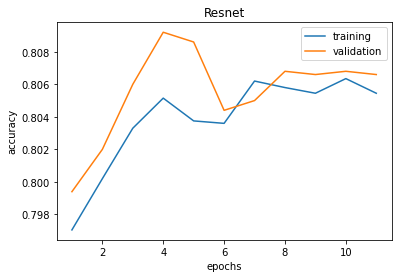

In [28]:
plt.plot(range(1, len(history.history['accuracy']) + 1), history.history['accuracy'])
plt.plot(range(1, len(history.history['val_accuracy']) + 1), history.history['val_accuracy'])
plt.title("Resnet")
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.legend(['training', 'validation'])

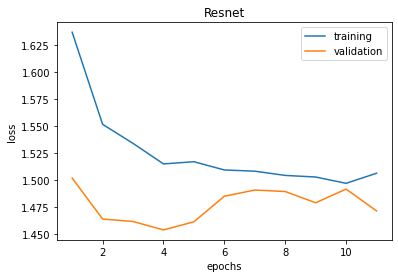

In [32]:
plt.plot(range(1, len(history.history['loss']) + 1), history.history['loss'])
plt.plot(range(1, len(history.history['val_loss']) + 1), history.history['val_loss'])
plt.title("Resnet")
plt.xlabel("epochs")
plt.ylabel("loss")
plt.legend(['training', 'validation'])

In [34]:
scores = model.evaluate(test_data)

157/157 [==============================] - 770s 5s/step - loss: 1.4922 - accuracy: 0.8051 - precision: 0.7783 - recall: 0.0358 - auc: 0.6713


In [35]:
print("Accuracy:", scores[1])
print("Precision:", scores[2])
print("Recall:", scores[3])
print("AUC:", scores[4])

Accuracy: 0.8051205277442932
Precision: 0.7782608866691589
Recall: 0.03579999879002571
AUC: 0.6713152527809143
